# Visualizing the model and gradients under noise

## Aim 1: Inference vs Training SNR vs Performance
* Take/Generate data with a given small UCI-Iris model.
* Include sweeps over training and inference noise levels.
* Plot a heatmap with training and inference SNR values on the axes and the color representing model accuracy.
* Generate data for training a model with noise and without. Consider the noise that gave the best performance perhaps! Plot a heatmap (2x2) grid.

## Aim 2: Visualizing gradients
* This plot should vefiry that the approx gradients and true gradients for the model are (almost) equal.
* Start with the same UCI-Iris model. Train one model with sigmoidal activation and another with TriDENT. Collect gradients of the model as they are training. 
  * Say $\mathbf{g}^l_s$ and $\mathbf{g}^l_t$ are the gradients in layer $l$ of the model. Then computing the cosine similarity: $$\cos(a) = \frac{\mathbf{g}^l_s \cdot \mathbf{g}^l_t}{||\mathbf{g}^l_s|| ||\mathbf{g}^l_t||}$$ should be clustered close to $1$

In [112]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")


*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


## Sanity Check: Plot the gradients

In [3]:
def exact_grad_fn(
    x,
    threshold,
    noise_std,
    noise_mean,
    scaling_factor = 1.0,
    ):

    grad = 2*scaling_factor*jax.scipy.stats.norm.pdf(x=threshold, loc=x, scale=noise_std)
    return grad

def trident_grad(
    x,
    threshold,
    noise_std,
    noise_mean,
    scaling_factor = 1.0,
    ):

    grad = 2*scaling_factor*jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std)*(1 - jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std))

    return grad


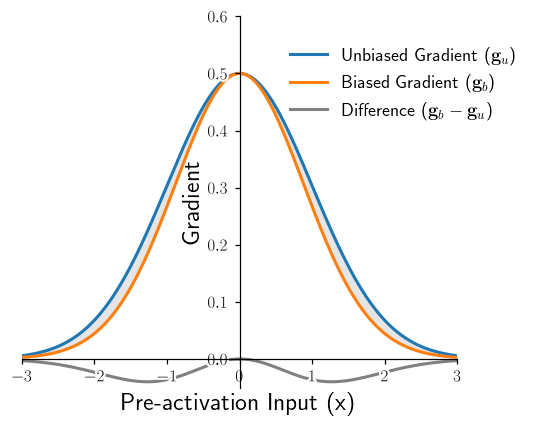

In [31]:
x_test = jnp.linspace(-3, 3, 500)

std = 1.0
ex_sf = jnp.sqrt(2*jnp.pi)*std/4
tri_grads = jax.vmap(trident_grad, in_axes=(0, None, None, None, None))(x_test, 0.0, std, 0.0, 1.0)
ex_grads = jax.vmap(exact_grad_fn, in_axes=(0, None, None, None, None))(x_test, 0.0, std, 0.0, ex_sf)

fig, ax = plt.subplots(dpi=110, figsize=(5, 4))
ax.plot(x_test, ex_grads, lw=2, label=r"Unbiased Gradient ($\mathbf{g}_u$)", zorder=-1)
ax.plot(x_test, tri_grads, lw=2, label=r"Biased Gradient ($\mathbf{g}_b$)", zorder=-1)
ax.plot(x_test, tri_grads - ex_grads, lw=2, label=r"Difference ($\mathbf{g}_b - \mathbf{g}_u$)", zorder=-1, color="0.5")
ax.fill_between(x_test, tri_grads, ex_grads, alpha=0.2, zorder=-2, color="0.5")
ax.set_xlabel("Pre-activation Input (x)", fontsize=16, loc='center')
ax.set_ylabel("Gradient", fontsize=16, loc="center", labelpad=2.3)
ax.set_ylim(-0.05, 0.6)
ax.set_xlim(-3, 3)
ax.spines[['bottom', 'left']].set_position('zero')
ax.tick_params(axis='both', which='major', labelsize=11, zorder=1)
ax.legend(frameon=False, fontsize=12, loc=(0.6, 0.7))

path_effect = [pe.withStroke(linewidth=3, foreground='w')]

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_path_effects(path_effect)
    label.set_zorder(5)

sns.despine()

plt.tight_layout()

save_plot_ = False

if save_plot_:
    fig.savefig(os.path.join(FIGURES_PATH, f"gradients_diff_{today}.pdf"), bbox_inches="tight", dpi=300)

## Using SNR data

In [27]:
# use the dataset: snr_sweep_uci_iris_2026-05-13.pkl
snr_data = pickle.load(open(os.path.join(DATA_PATH, "snr_sweep_uci_iris_2026-05-13.pkl"), "rb"))
snr_data = pd.DataFrame(snr_data)
snr_data.head()

,accuracy,sparsity,snr,noise_std,model_index,resample_index,training_snr,training_sparsity
0,0.822222,0.0,95.178612,0.00001,0,0,55.470749,[]
1,0.822222,0.0,95.178612,0.00001,0,1,55.470749,[]
2,0.822222,0.0,95.178612,0.00001,0,2,55.470749,[]
3,0.822222,0.0,95.178612,0.00001,0,3,55.470749,[]
4,0.822222,0.0,95.178612,0.00001,0,4,55.470749,[]


   noise_std  model_index  accuracy         snr  training_snr
0    0.00001            0  0.822222   95.178612     55.470749
1    0.00001            1  1.000000   94.980667     35.271343
2    0.00001            2  0.955556   96.037628     16.292866
3    0.00001            3  0.688889   99.969452      0.203960
4    0.00001            4  0.688889  107.383286    -12.406296


Text(0, 0.5, 'Test SNR (dB)')

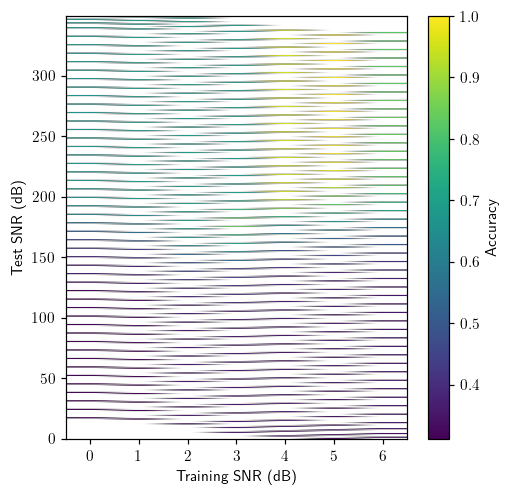

In [ ]:
# avg_snr_data = snr_data.groupby(["noise_std", "model_index"]).agg({
#     "accuracy": "mean",
#     "snr": "mean",
#     "training_snr": "mean"
# }).reset_index()

# print(avg_snr_data.head())

# # pivot the data for heatmap
# snr_heatmap_data = avg_snr_data.pivot(index="snr", columns="training_snr", values="accuracy")

# # plot a heatmap x-axis: training_snr, y-axis: snr, color: accuracy
# fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
# plt.imshow(snr_heatmap_data, cmap="viridis", origin="lower", aspect="auto")
# plt.colorbar(label="Accuracy")
# plt.xlabel("Training SNR (dB)")
# plt.ylabel("Test SNR (dB)")

## Using Noise-Performance Data

In [55]:
# load the noise-performance data
noise_perf_comp_data = pickle.load(open(os.path.join(DATA_PATH, "noise_perf_comp_uci_iris_inference_data_2026-06-10.pkl"), "rb"))

for key in noise_perf_comp_data.keys():
    print(f"Key: {key}, shape: {len(noise_perf_comp_data[key])}")

noise_perf_data = pd.DataFrame(noise_perf_comp_data)

# replace inf with 1000 for plotting
noise_perf_data["inference_snr"] = noise_perf_data["inference_snr"].replace(jnp.inf, 1000)
noise_perf_data["training_snr"] = noise_perf_data["training_snr"].replace(jnp.inf, 1000)


noise_perf_data.head()

Key: accuracy, shape: 900
Key: inference_snr, shape: 900
Key: training_snr, shape: 900
Key: noise_std, shape: 900
Key: model_index, shape: 900
Key: resample_index, shape: 900


,accuracy,inference_snr,training_snr,noise_std,model_index,resample_index
0,0.755556,1000.0,1000.0,0.0,0,0
1,0.755556,1000.0,1000.0,0.0,0,1
2,0.755556,1000.0,1000.0,0.0,0,2
3,0.755556,1000.0,1000.0,0.0,0,3
4,0.755556,1000.0,1000.0,0.0,0,4


In [83]:
# round snr to the nearest integer for grouping
clean_npf_df = noise_perf_data.copy()
clean_npf_df["training_snr"] = clean_npf_df["training_snr"].round().astype(float)
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].round().astype(float)

# combine inference snr = 34 and 35 under 34 --> ignoring effects of small variations in noisy inference
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].replace(35.0, 34.0)

# combine inference snr = 14 and 15 under 15 --> ignoring effects of small variations in noisy inference
clean_npf_df["inference_snr"] = clean_npf_df["inference_snr"].replace(14.0, 15.0)

clean_npf_df.head()

,accuracy,inference_snr,training_snr,noise_std,model_index,resample_index
0,0.755556,1000.0,1000.0,0.0,0,0
1,0.755556,1000.0,1000.0,0.0,0,1
2,0.755556,1000.0,1000.0,0.0,0,2
3,0.755556,1000.0,1000.0,0.0,0,3
4,0.755556,1000.0,1000.0,0.0,0,4


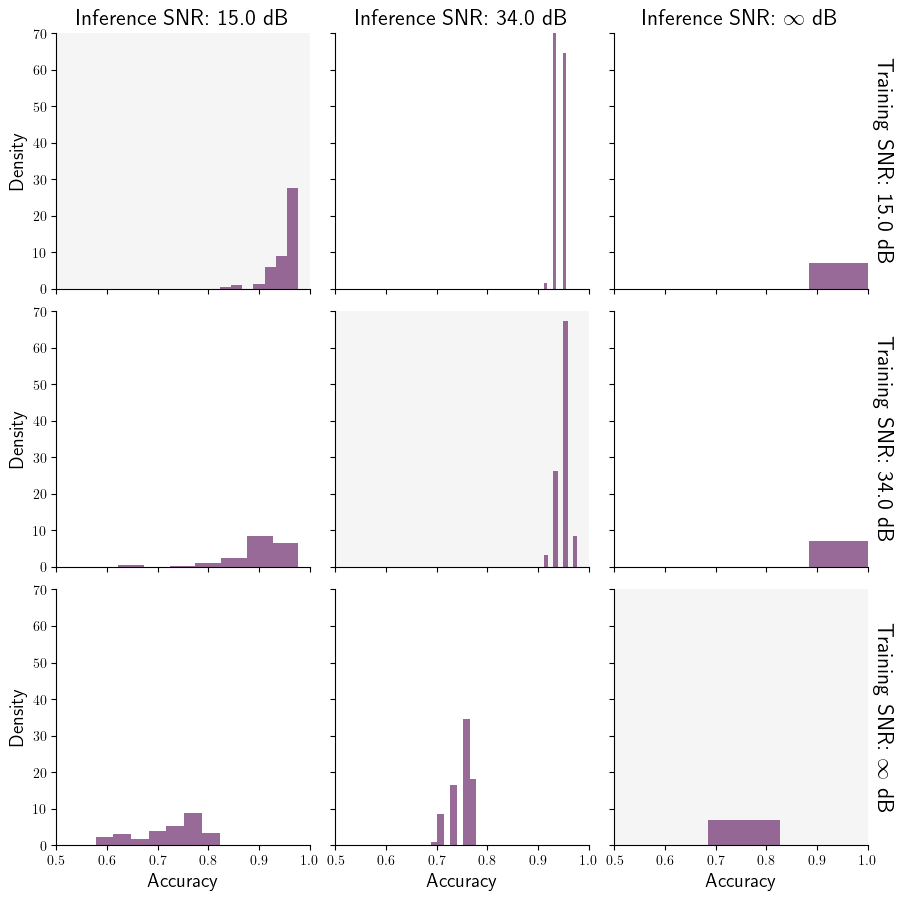

In [119]:
# plotting histograms for every configuration of noise level
flare_pal = sns.color_palette("flare")
g = sns.FacetGrid(clean_npf_df, row="training_snr", col="inference_snr", margin_titles=True, palette=flare_pal)
g.map(sns.histplot, "accuracy", bins=7, kde=False, edgecolor=None, stat="density", color=flare_pal[-1], alpha=0.7)
g.set(xlim=(0.5, 1.), ylim=(0, 70))
g.set_titles(row_template="Training SNR: {row_name} dB", col_template="Inference SNR: {col_name} dB", size=16)
# replace 1000 by symbol infinity

g.set_axis_labels("Accuracy", "Density", size=14)

for ax in g.axes.flat:
    # 1. Update the column titles (located at the top of the grid)
    current_title = ax.get_title()
    if "1000.0" in current_title:
        ax.set_title(current_title.replace("1000.0", r"$\infty$"), size=16)
    
    # 2. Update the row titles (located on the right margin)
    # Seaborn stores these margin titles as text objects within the axis
    for text in ax.texts:
        current_text = text.get_text()
        if "1000.0" in current_text:
            text.set_text(current_text.replace("1000.0", r"$\infty$"))

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == col_val:
        ax.set_facecolor("0.96")

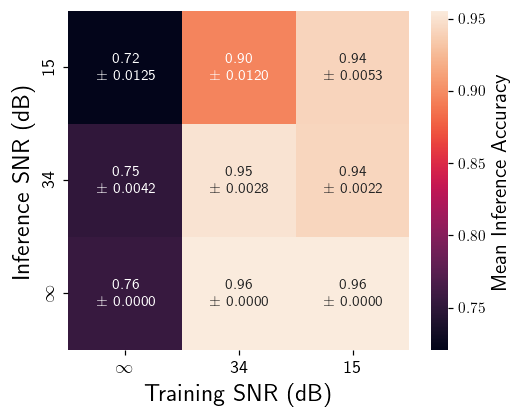

In [172]:
# set flag to save figures
_save_fig = False

# heatmap: x-axis: training_snr, y-axis: inference_snr, color: accuracy 
flare_pal = sns.color_palette("rocket", as_cmap=True)
hist_df = clean_npf_df.groupby(["training_snr", "inference_snr"]).agg({"accuracy": ["mean", "sem"]}).reset_index()

mean_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "mean"))
sem_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "sem"))
sem_pivot = 1.96*sem_pivot

# generate the correct annotation labels
annot_labels = np.empty_like(mean_pivot, dtype=object)

for r in range(mean_pivot.shape[0]):
    for c in range(mean_pivot.shape[1]):
        mean_val = mean_pivot.iloc[r, c]
        sem_val = sem_pivot.iloc[r, c]
        annot_labels[r, c] = f"{mean_val:.2f}\n ± {sem_val:.4f}"

fig, ax = plt.subplots(dpi=110, figsize=(5, 4))
sns.heatmap(
    mean_pivot,
    annot=annot_labels,
    fmt="",
    cmap=flare_pal,
    cbar_kws={"label": "Mean Accuracy"},
    ax=ax

)

ax.invert_xaxis()

cbar = ax.collections[0].colorbar
cbar.set_label("Mean Inference Accuracy", fontsize=14)
cbar.ax.tick_params(labelsize=10)


ax.set_xticklabels([f"{int(label)}" if label != 1000 else r"$\infty$" for label in mean_pivot.columns], fontsize=12)
ax.set_yticklabels([f"{int(label)}" if label != 1000 else r"$\infty$" for label in mean_pivot.index], fontsize=12)

ax.set_xlabel("Training SNR (dB)", fontsize=16)
ax.set_ylabel("Inference SNR (dB)", fontsize=16)

if _save_fig:
    today = date.today().isoformat()
    fig.savefig(os.path.join(FIGURES_PATH, f"noise_perf_heatmap_uci_iris_{today}.pdf"), bbox_inches="tight", dpi=300)

<Axes: xlabel='training_snr', ylabel='inference_snr'>

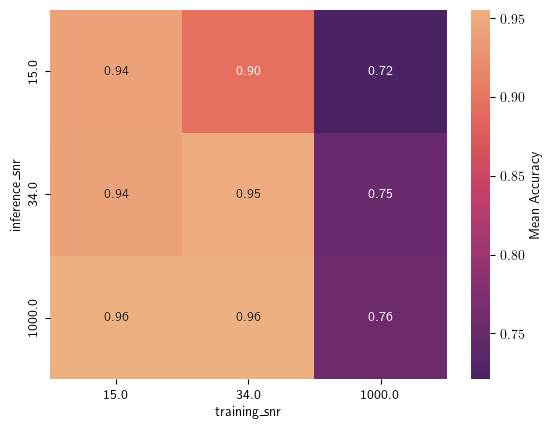

In [136]:
# heatmap: x-axis: training_snr, y-axis: inference_snr, color: accuracy: ONLY THE MEAN ACCURACY
flare_pal = sns.color_palette("flare_r", as_cmap=True)
hist_df = clean_npf_df.groupby(["training_snr", "inference_snr"]).agg({"accuracy": ["mean", "sem"]}).reset_index()

mean_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "mean"))
sem_pivot = hist_df.pivot(index="inference_snr", columns="training_snr", values=("accuracy", "sem"))
sem_pivot = 1.96*sem_pivot

# generate the correct annotation labels
annot_labels = np.empty_like(mean_pivot, dtype=object)

# for r in range(mean_pivot.shape[0]):
#     for c in range(mean_pivot.shape[1]):
#         mean_val = mean_pivot.iloc[r, c]
#         sem_val = sem_pivot.iloc[r, c]
#         annot_labels[r, c] = f"{mean_val:.2f}\n±{sem_val:.4f}"

fig, ax = plt.subplots()
sns.heatmap(
    mean_pivot,
    annot=True,
    fmt=".2f",
    cmap=flare_pal,
    cbar_kws={"label": "Mean Accuracy"},
    ax=ax

)

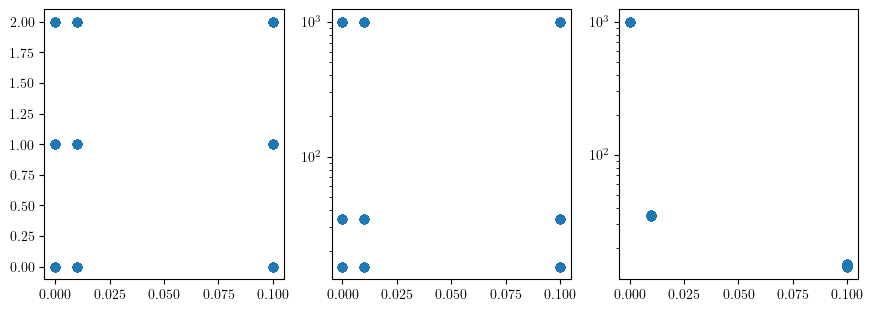

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.5))
ax[0].plot(noise_perf_data['noise_std'], noise_perf_data['model_index'], marker="o", lw=0, alpha=0.1)
ax[1].plot(noise_perf_data['noise_std'], noise_perf_data['training_snr'], marker="o", lw=0, alpha=0.1)
ax[2].plot(noise_perf_data['noise_std'], noise_perf_data['inference_snr'], marker="o", lw=0, alpha=0.1)

for i in range(1, 3):
    ax[i].set_yscale("log")

In [150]:
a = 1.645
print(r"${a} \eta $")

${a} \eta $


In [77]:
noise_perf_data['training_snr'].unique()

array([1000.        ,   34.43383789,   15.2316103 ])

## Comparing Gradients

In [11]:
# load the data: gradients_comparison: 2026-06-18 files also have gradient norms
cosine_data_n2 = pickle.load(open(os.path.join(DATA_PATH, "cosine_similarity_accuracy_comparison_uci_iris_2026-06-18_noise_0.010.pkl"), "rb"))
cosine_data_n1 = pickle.load(open(os.path.join(DATA_PATH, "cosine_similarity_accuracy_comparison_uci_iris_2026-06-18_noise_0.100.pkl"), "rb"))

# print the configs
print(f"Configs for cosine_data_n2: {cosine_data_n2['configs']}")
print(f"Configs for cosine_data_n1: {cosine_data_n1['configs']}")

cosine_data_n2 = pd.DataFrame(cosine_data_n2['state'])
cosine_data_n1 = pd.DataFrame(cosine_data_n1['state'])


# print the heads
print(cosine_data_n2.head())
print(cosine_data_n1.head())



Configs for cosine_data_n2: {'train_steps': 30000, 'eval_every': 100, 'learning_rate': 0.0001, 'threshold': 0.0, 'noise_std': 0.01, 'layers': [4, 32, 3], 'num_resamples': 1, 'seed': 0, 'rng_headers': ['params+0', 'dropout+1', 'activation+2', 'next+3']}
Configs for cosine_data_n1: {'train_steps': 30000, 'eval_every': 100, 'learning_rate': 0.0001, 'threshold': 0.0, 'noise_std': 0.1, 'layers': [4, 32, 3], 'num_resamples': 1, 'seed': 0, 'rng_headers': ['params+0', 'dropout+1', 'activation+2', 'next+3']}
   step  cosine_similarity  trident_grad_norm  exact_grad_norm  \
0     0           0.835381           0.006241         0.013458   
1   100           0.937429           0.017487         0.012679   
2   200           0.598104           0.003499         0.010007   
3   300           0.000000           0.000000         0.009479   
4   400           0.562224           0.015001         0.004727   

   inference_accuracy_trident  inference_accuracy_exact  
0                    0.200000           

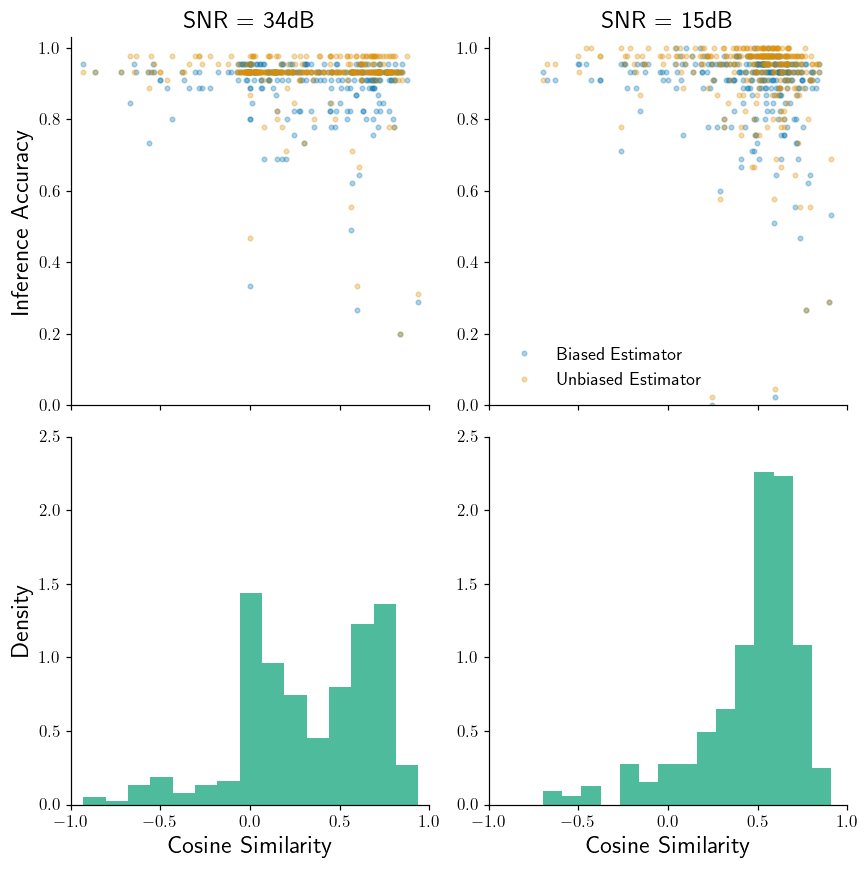

In [304]:
# plotting 
today = date.today().isoformat()
_save_fig = False

cb_pal = sns.color_palette("colorblind")
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110,sharex=True)

for axs, i in zip(ax.flatten(), range(4)):
    # left size: SNR = 34dB, right side SNR = 15dB
    if i < 2:
        if i == 0:
            axs.plot(cosine_data_n2["cosine_similarity"],
            cosine_data_n2["inference_accuracy_trident"],
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[0], 
            label="Biased Estimator")

            axs.plot(cosine_data_n2["cosine_similarity"], 
            cosine_data_n2["inference_accuracy_exact"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[1], 
            label="Unbiased Estimator")

            axs.set_ylabel("Inference Accuracy", fontsize=16)
            # axs.set_xlabel("Cosine Similarity", fontsize=16)

            # axs.set_ylim(-1.0, 1.0)
            # axs.set_xlim(0.1, 1.0)

            axs.set_title("SNR = 34dB", fontsize=16)
                

        else:

            axs.plot(cosine_data_n1["cosine_similarity"], 
            cosine_data_n1["inference_accuracy_trident"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[0],
            label="Biased Estimator")

            axs.plot(cosine_data_n1["cosine_similarity"], 
            cosine_data_n1["inference_accuracy_exact"], 
            marker='o', 
            lw=0,
            alpha=0.3, 
            markersize=3, 
            color=cb_pal[1], 
            label="Unbiased Estimator"
            )


            # axs.set_ylim(-1.0, 1.0)
            # axs.set_xlim(0.1, 1.01)
            # axs.set_ylabel("Inference Accuracy", fontsize=16)
            # axs.set_xlabel("Cosine Similarity", fontsize=16)
            axs.set_title("SNR = 15dB", fontsize=16)

            axs.legend(frameon=False, fontsize=12)

    else:
        if i == 2:
            sns.histplot(
                data=cosine_data_n2,
                x="cosine_similarity",
                bins=15,
                edgecolor=None,
                stat="density",
                color=cb_pal[2],
                alpha=0.7,
                ax=axs
            )
            axs.set_ylabel("Density", fontsize=16)
            axs.set_xlabel("Cosine Similarity", fontsize=16)

        else:
            sns.histplot(
                data=cosine_data_n1,
                x="cosine_similarity",
                bins=15,
                edgecolor=None,
                stat="density",
                color=cb_pal[2],
                alpha=0.7,
                ax=axs
            )
            axs.set_xlabel("Cosine Similarity", fontsize=16)
            axs.set_ylabel("", fontsize=16)


    sns.despine(ax=axs)

ax[0,0].sharey(ax[0,1])
ax[1,0].sharey(ax[1,1])

ax[0,0].set_ylim(0.0, 1.03)
ax[1,0].set_ylim(0, 2.5)
ax[1, 0].set_xlim(-1, 1)
ax[1, 1].set_xlim(-1, 1)

for axs in ax.ravel():
    axs.tick_params(axis='both', labelsize=11)

plt.tight_layout()
if _save_fig:
    fig.savefig(os.path.join(FIGURES_PATH, f"cosine_sim_accuracy_uci_iris_{today}.pdf"), bbox_inches="tight", dpi=300)

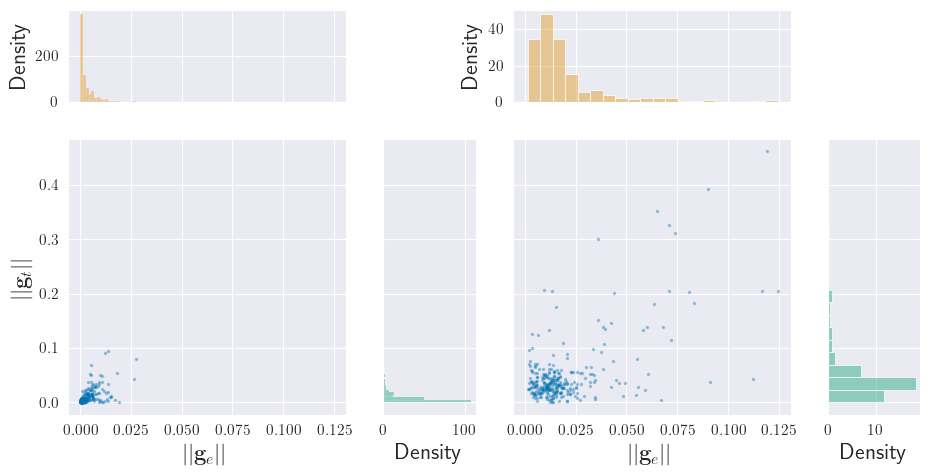

In [116]:
## plotting gradient norms
cb_pal = sns.color_palette("colorblind")
_logscale = False
_markersize=1.5
_edgecolor="w"
fig = plt.figure(figsize=(11, 11))
gs = GridSpec(4, 4, width_ratios=[3, 1, 3, 1], height_ratios=[1, 3, 1, 3], hspace=0.2)

with sns.axes_style("darkgrid"):
    ax5 = fig.add_subplot(gs[4]) # anchor plot for SNR = 34dB
    ax7 = fig.add_subplot(gs[6], sharex=ax5, sharey=ax5) # anchor plot for SNR = 15dB

    ax1 = fig.add_subplot(gs[0], sharex=ax5) # top left distribution
    ax2 = fig.add_subplot(gs[1]) # null
    ax3 = fig.add_subplot(gs[2], sharex=ax7) # top right distribution
    ax4 = fig.add_subplot(gs[3]) # null
    ax6 = fig.add_subplot(gs[5], sharey=ax5) # bottom right distribution
    ax8 = fig.add_subplot(gs[7], sharey=ax7)

    # turn off ax_null
    ax2.axis("off")
    ax4.axis("off")

    # for reference add texts to the axes: TODO -> remove later
    # ax1.text(0.5, 0.5, "ax1: Exact gradients norm distribution", ha='center', va='center', fontsize=12)
    # ax3.text(0.5, 0.5, "ax3: TriDENT gradients norm distribution", ha='center', va='center', fontsize=12, rotation=90)
    # ax2.text(0.5, 0.5, "ax2: Scatter plot - norms", ha='center', va='center', fontsize=12)

    # add the scatter plot
    ax5.plot(cosine_data_n2["exact_grad_norm"], cosine_data_n2["trident_grad_norm"], marker='o', lw=0, alpha=0.3, markersize=_markersize, color=cb_pal[0])
    ax5.set_xlabel(r"$ || \mathbf{g}_e ||$", fontsize=16)
    ax5.set_ylabel(r"$ || \mathbf{g}_t ||$", fontsize=16)
    # ax5.set_aspect("equal")

    # sharing the axes
    # ax1.sharex(ax5)
    # ax6.sharey(ax5)
    if _logscale:
        ax5.set_xscale("log")
        ax5.set_yscale("log")
        ax5.set_ylim(1e-1, 1e-15)

    # add inset plot to ax5 zooming in near zero
    # ax5_ins = ax5.inset_axes([0.6, 0.6, 0.3, 0.3])
    # ax5_ins.plot(cosine_data_n2["exact_grad_norm"], cosine_data_n2["trident_grad_norm"], marker='o', lw=0, alpha=0.3, markersize=_markersize, color=cb_pal[0])
    # # ax5_ins.set_xscale("log")
    # # ax5_ins.set_yscale("log")
    # ax5_ins.set_xlim(0.0, 10e-3)
    # ax5_ins.set_ylim(0.0, 10e-3)
    # ax5_ins.set_aspect("equal")

    # add the histogram on ax1
    sns.histplot(
        data = cosine_data_n2,
        x = "exact_grad_norm",
        bins=20,
        edgecolor=_edgecolor,
        lw=0.1,
        stat="density",
        alpha=0.4,
        ax=ax1,
        color=cb_pal[1]
    )

    ax1.set_xlabel("")
    ax1.tick_params(axis='x', labelbottom=False)
    ax1.set_ylabel("Density", fontsize=16)

    # add the histogram on ax6
    sns.histplot(
        data = cosine_data_n2,
        y = "trident_grad_norm",
        bins=20,
        edgecolor=_edgecolor,
        lw=0.1,
        stat="density",
        alpha=0.4,
        ax=ax6,
        color=cb_pal[2]
    )
    ax6.set_ylabel("")
    ax6.set_xlabel("Density", fontsize=16)
    ax6.tick_params(axis='y', labelleft=False)

# plot the scatter plot on ax7
ax7.plot(
    cosine_data_n1["exact_grad_norm"],
    cosine_data_n1["trident_grad_norm"],
    marker='o',
    lw=0,
    alpha=0.3,
    markersize=_markersize,
    color=cb_pal[0],
)

ax7.tick_params(axis='y', labelleft=False)
ax7.set_xlabel(r"$ || \mathbf{g}_e ||$", fontsize=16)

# ax5.sharey(ax7)
# ax5.sharex(ax7)

# add the histogram on ax3
sns.histplot(
    data = cosine_data_n1,
    x = "exact_grad_norm",
    bins=20,
    edgecolor=_edgecolor,
    lw=0.5,
    stat="density",
    alpha=0.4,
    ax=ax3,
    color=cb_pal[1]
)

ax3.set_xlabel("")
ax3.tick_params(axis='x', labelbottom=False)
ax3.set_ylabel("Density", fontsize=16)

# add histogram on ax8
sns.histplot(
    data=cosine_data_n1,
    y="trident_grad_norm",
    bins=20,
    edgecolor=_edgecolor,
    lw=0.5,
    stat="density",
    alpha=0.4,
    ax=ax8,
    color=cb_pal[2]
)

ax8.set_ylabel("")
ax8.set_xlabel("Density", fontsize=16)
ax8.tick_params(axis='y', labelleft=False)

for ax in [ax1, ax3, ax5, ax6, ax7, ax8]:
    ax.tick_params(axis='both', labelsize=11)

# plt.tight_layout()

## SNR conceptual plot

In [2]:
def dropout_snr(
    N: int, # number of neurons in a layer
    p: float, # dropout average probability
    **kwargs
    ):

    """
    Calculates SNR for a layer with N neurons and p as probabilityy of success i.e. neuron being active
    """

    assert p > 0 and p < 1, "Dropout probability must be between 0 and 1"

    snr_nw = 10*jnp.log10(N)
    snr_neuron = 10*jnp.log10(p/(1-p))
    total_snr = snr_nw + snr_neuron

    return total_snr, [snr_nw, snr_neuron]

def sqnr(
    N: int, # bit resolution of the quantizer
    **kwargs
    ):

    """
    Calculates the Signal-to-Quantization-Noise Ratio (SQNR) for a given bit resolution N.
    """

    sqnr = 6.02*N + 1.76
    return sqnr



In [163]:
## compute the boundaries
gpu_min_train_snr, _ = dropout_snr(N=32, p=0.4) # for prototype network with p=0.5
gpu_max_train_snr, _ = dropout_snr(N=32, p=0.9) # for prototype network with p=0.9

gpu_4b_inf_snr = sqnr(N=4) # for 4-bit edge quantized inference
gpu_min_inf_snr = sqnr(N=8) # for 8-bit edge quantized inference
gpu_max_inf_snr = sqnr(N=32) # for 32-bit floating point inference

# print the boundaries
print(f"GPU Training SNR bounds: {gpu_min_train_snr:.2f} dB to {gpu_max_train_snr:.2f} dB")
print(f"GPU Inference SNR bounds: {gpu_min_inf_snr:.2f} dB to {gpu_max_inf_snr:.2f} dB")

# CIM bounds
limits_ = [1e0, 1e3]
cim_bounds = jnp.linspace(limits_[0], limits_[1], num=100)

GPU Training SNR bounds: 13.29 dB to 24.59 dB
GPU Inference SNR bounds: 49.92 dB to 194.40 dB


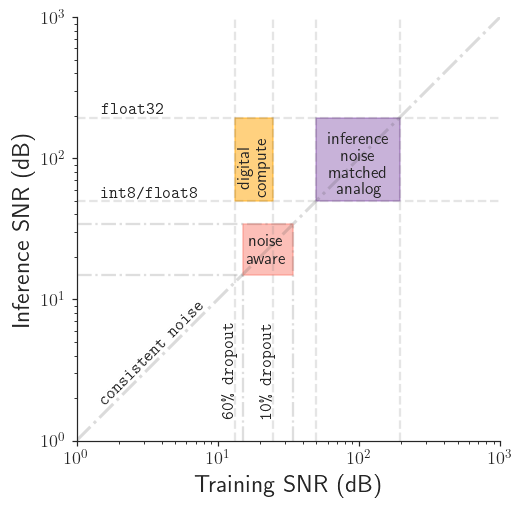

In [ ]:
## plotting: 8-bit inference
with sns.axes_style("ticks"):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
    alpha_ = 0.2

    # set log scale
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)

    # equalize the axes aspect ratio
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(limits_[0], limits_[1])
    ax.set_ylim(limits_[0], limits_[1])

    ax.set_xlabel("Training SNR (dB)", fontsize=16)
    ax.set_ylabel("Inference SNR (dB)", fontsize=16)

    ax.tick_params(axis="both", labelsize=12)


    # plotting the GPU bounds
    ax.axvline(x=gpu_min_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_min_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)

    # annotate GPU bounds
    ax.text(y=gpu_max_inf_snr*1.05, x=1.5, s=r"\texttt{float32}", fontsize=11)
    ax.text(y=gpu_min_inf_snr*1.05, x=1.5, s=r"\texttt{int8/float8}", fontsize=11)
    ax.text(x=gpu_min_train_snr*0.80, y=1.5, s=r"\texttt{60\% dropout}", fontsize=11, rotation=90)
    ax.text(x=gpu_max_train_snr*0.80, y=1.5, s=r"\texttt{10\% dropout}", fontsize=11, rotation=90)

    # fill between the GPU bounds
    ax.fill_betweenx(y=[gpu_min_inf_snr, gpu_max_inf_snr],
                     x1=gpu_min_train_snr,
                     x2=gpu_max_train_snr,
                     color="orange",
                     alpha=0.5)
    
    # plotting the CIM bounds
    ax.plot(cim_bounds, cim_bounds, color="0.3", ls="-.", lw=2, alpha=alpha_)
    ax.axvline(x=gpu_min_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.fill_betweenx(
        y=[gpu_min_inf_snr, gpu_max_inf_snr],
        x1=gpu_min_inf_snr,
        x2=gpu_max_inf_snr,
        color="indigo",
        alpha=0.3
    )
    ax.text(x=1.4, y=1.8, s=r"\texttt{consistent noise}", fontsize=11, rotation=45)

    # plotting the network bounds -- 15-34dB
    ax.vlines(x=15, ymax=15, ymin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.vlines(x=34, ymax=34, ymin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.hlines(y=15, xmax=15, xmin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.hlines(y=34, xmax=34, xmin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.fill_betweenx(y=[15, 34], x1=15, x2=34, color="salmon", alpha=0.5)

    # annotating inside the boxes
    ax.text(x=18, y=55, s="digital \n compute", 
            fontsize=11,
            ha="center",
            rotation=90,
            )
    
    ax.text(x=100, y=55, s="inference\n noise\nmatched\n analog", 
            fontsize=11,
            ha="center",
            rotation=0,
            )
    
    ax.text(x=22, y=18, s="noise\naware", 
            fontsize=11,
            ha="center",
            rotation=0,
            )


    sns.despine(ax=ax)

    _save_plot = False
    if _save_plot:
        fig.savefig(os.path.join(FIGURES_PATH, f"snr_boundaries_32_hl_inf_8_{today}.pdf"), bbox_inches="tight", dpi=300)


In [ ]:
## TODO: CHECKPOINTING FOR SLIDES -> save in SLIDES_PATH
## plotting: 8-bit inference
with sns.axes_style("ticks"):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
    alpha_ = 0.2

    # set log scale
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)

    # equalize the axes aspect ratio
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(limits_[0], limits_[1])
    ax.set_ylim(limits_[0], limits_[1])

    ax.set_xlabel("Training SNR (dB)", fontsize=16)
    ax.set_ylabel("Inference SNR (dB)", fontsize=16)

    ax.tick_params(axis="both", labelsize=12)


    # plotting the GPU bounds
    ax.axvline(x=gpu_min_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_min_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)

    # annotate GPU bounds
    ax.text(y=gpu_max_inf_snr*1.05, x=1.5, s=r"\texttt{float32}", fontsize=11)
    ax.text(y=gpu_min_inf_snr*1.05, x=1.5, s=r"\texttt{int8/float8}", fontsize=11)
    ax.text(x=gpu_min_train_snr*0.80, y=1.5, s=r"\texttt{60\% dropout}", fontsize=11, rotation=90)
    ax.text(x=gpu_max_train_snr*0.80, y=1.5, s=r"\texttt{10\% dropout}", fontsize=11, rotation=90)

    # fill between the GPU bounds
    ax.fill_betweenx(y=[gpu_min_inf_snr, gpu_max_inf_snr],
                     x1=gpu_min_train_snr,
                     x2=gpu_max_train_snr,
                     color="orange",
                     alpha=0.5)
    
    # plotting the CIM bounds
    ax.plot(cim_bounds, cim_bounds, color="0.3", ls="-.", lw=2, alpha=alpha_)
    ax.axvline(x=gpu_min_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.fill_betweenx(
        y=[gpu_min_inf_snr, gpu_max_inf_snr],
        x1=gpu_min_inf_snr,
        x2=gpu_max_inf_snr,
        color="indigo",
        alpha=0.3
    )
    ax.text(x=1.4, y=1.8, s=r"\texttt{consistent noise}", fontsize=11, rotation=45)

    # plotting the network bounds -- 15-34dB
    ax.vlines(x=15, ymax=15, ymin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.vlines(x=34, ymax=34, ymin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.hlines(y=15, xmax=15, xmin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.hlines(y=34, xmax=34, xmin=limits_[0], color="0.5", ls="-.", lw=1.5, alpha=alpha_*1.3)
    ax.fill_betweenx(y=[15, 34], x1=15, x2=34, color="salmon", alpha=0.5)

    # annotating inside the boxes
    ax.text(x=18, y=55, s="digital \n compute", 
            fontsize=11,
            ha="center",
            rotation=90,
            )
    
    ax.text(x=100, y=55, s="inference\n noise\nmatched\n analog", 
            fontsize=11,
            ha="center",
            rotation=0,
            )
    
    ax.text(x=22, y=18, s="noise\naware", 
            fontsize=11,
            ha="center",
            rotation=0,
            )


    sns.despine(ax=ax)

    _save_plot = False
    if _save_plot:
        fig.savefig(os.path.join(SLIDES_PATH, f"snr_boundaries_32_hl_inf_8_{today}.pdf"), bbox_inches="tight", dpi=300)

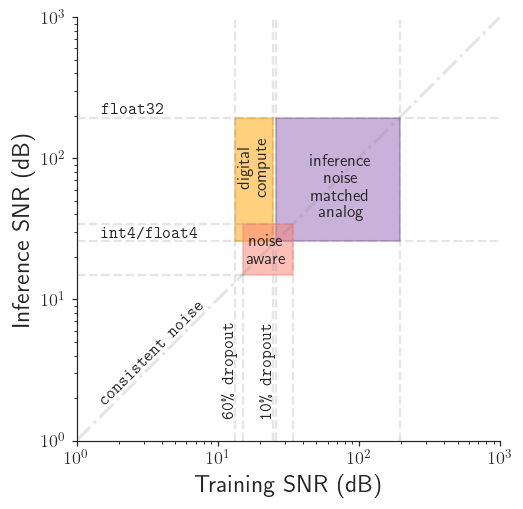

In [ ]:
## plotting: 4-bit inference
with sns.axes_style("ticks"):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
    alpha_ = 0.2

    # set log scale
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)

    # equalize the axes aspect ratio
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(limits_[0], limits_[1])
    ax.set_ylim(limits_[0], limits_[1])

    ax.set_xlabel("Training SNR (dB)", fontsize=16)
    ax.set_ylabel("Inference SNR (dB)", fontsize=16)

    ax.tick_params(axis="both", labelsize=12)


    # plotting the GPU bounds
    ax.axvline(x=gpu_min_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_train_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_4b_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axhline(y=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)

    # annotate GPU bounds
    ax.text(y=gpu_max_inf_snr*1.05, x=1.5, s=r"\texttt{float32}", fontsize=11)
    ax.text(y=gpu_4b_inf_snr*1.05, x=1.5, s=r"\texttt{int4/float4}", fontsize=11)
    ax.text(x=gpu_min_train_snr*0.80, y=1.5, s=r"\texttt{60\% dropout}", fontsize=11, rotation=90)
    ax.text(x=gpu_max_train_snr*0.80, y=1.5, s=r"\texttt{10\% dropout}", fontsize=11, rotation=90)

    # fill between the GPU bounds
    ax.fill_betweenx(y=[gpu_4b_inf_snr, gpu_max_inf_snr],
                     x1=gpu_min_train_snr,
                     x2=gpu_max_train_snr,
                     color="orange",
                     alpha=0.5)
    
    # plotting the CIM bounds
    ax.plot(cim_bounds, cim_bounds, color="0.5", ls="-.", lw=2, alpha=alpha_)
    ax.axvline(x=gpu_4b_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.axvline(x=gpu_max_inf_snr, color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.fill_betweenx(
        y=[gpu_4b_inf_snr, gpu_max_inf_snr],
        x1=gpu_4b_inf_snr,
        x2=gpu_max_inf_snr,
        color="indigo",
        alpha=0.3
    )
    ax.text(x=1.4, y=1.8, s=r"\texttt{consistent noise}", fontsize=11, rotation=45)

    # plotting the network bounds -- 15-34dB
    ax.vlines(x=15, ymax=15, ymin=limits_[0], color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.vlines(x=34, ymax=34, ymin=limits_[0], color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.hlines(y=15, xmax=15, xmin=limits_[0], color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.hlines(y=34, xmax=34, xmin=limits_[0], color="0.5", ls="--", lw=1.5, alpha=alpha_)
    ax.fill_betweenx(y=[15, 34], x1=15, x2=34, color="salmon", alpha=0.5)

    # annotating inside the boxes
    ax.text(x=18, y=55, s="digital \n compute", 
            fontsize=11,
            ha="center",
            rotation=90,
            )
    
    ax.text(x=75, y=38, s="inference\n noise\nmatched\n analog", 
            fontsize=11,
            ha="center",
            rotation=0,
            )
    
    ax.text(x=22, y=18, s="noise\naware", 
            fontsize=11,
            ha="center",
            rotation=0,
            )
    

    sns.despine(ax=ax)

    _save_plot = False
    if _save_plot:
        fig.savefig(os.path.join(FIGURES_PATH, f"snr_boundaries_32_hl_inf_4_{today}.pdf"), bbox_inches="tight", dpi=300)


## Plotting the loss landscape

In [41]:
# load the data
sigmoid_loss = pickle.load(open(os.path.join(DATA_PATH, "loss_vis_sigmoid_2026-06-30.pkl"), "rb"))
trident_34 = pickle.load(open(os.path.join(DATA_PATH, "loss_vis_trident_noise_0.100_2026-06-30.pkl"), "rb"))
trident_15 = pickle.load(open(os.path.join(DATA_PATH, "loss_vis_trident_noise_0.010_2026-06-30.pkl"), "rb"))

# unpacking the data
grid_sig, loss_surface_sig = sigmoid_loss['grid'], sigmoid_loss['loss_surface']
tri_34_grid, loss_surface_tr34 = trident_34['grid'], trident_34['loss_surface']
tri_15_grid, loss_surface_tr15 = trident_15['grid'], trident_15['loss_surface']

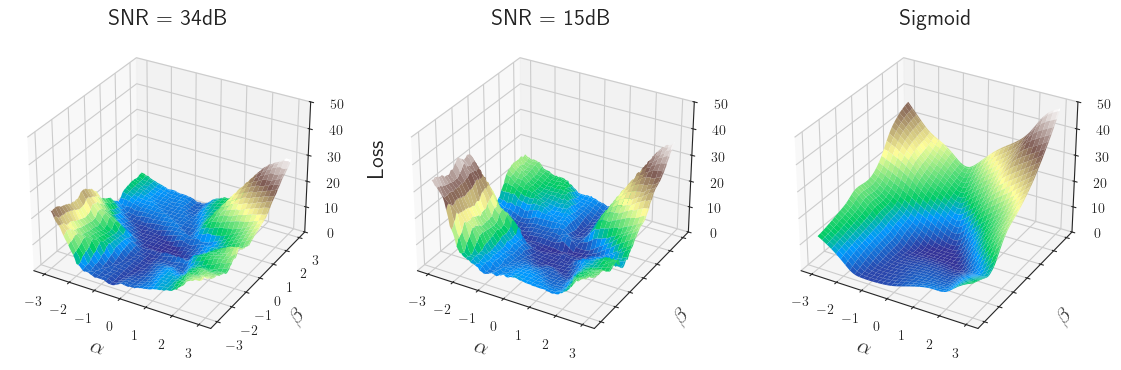

In [ ]:
# plotting figures
flare_pal = sns.color_palette("flare")
coolwarm_pal = sns.color_palette("coolwarm")

with sns.axes_style("ticks"):
    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), subplot_kw={'projection': '3d'}, sharex=True, sharey=True)

    # plotting the 34dB SNR model
    ax[0].plot_surface(tri_34_grid[0], tri_34_grid[1], loss_surface_tr34, edgecolor="none", lw=0, cmap="terrain")
    ax[0].set_title("SNR = 34dB", fontsize=16)

    # plotting the 15dB SNR model
    ax[1].plot_surface(tri_15_grid[0], tri_15_grid[1], loss_surface_tr15, edgecolor="none", lw=0, cmap="terrain")
    ax[1].set_title("SNR = 15dB", fontsize=16)

    # plotting the sigmoid
    ax[2].plot_surface(grid_sig[0], grid_sig[1], loss_surface_sig, edgecolor="none", lw=0, cmap="terrain")
    ax[2].set_title("Sigmoid", fontsize=16)

    for i, axs in enumerate([ax[0], ax[1], ax[2]]):
        axs.set_zlim(0, 50)
        axs.set_xlabel(r"$\alpha$", fontsize=16)
        axs.set_ylabel(r"$\beta$", fontsize=16)
        if i == 0:
            axs.set_zlabel(r"Loss", rotation=90, fontsize=16, labelpad=10)

# plt.tight_layout(rect=[0., 0., 0.9, 1.])
plt.subplots_adjust(left=0.02, right=0.95, bottom=0.05, top=0.95, wspace=0.1)

save_plot_ = False
if save_plot_:
    fig.savefig(os.path.join(FIGURES_PATH, f"loss_landscape_{today}.pdf"), bbox_inches='tight', dpi=300)

### Animating surface plots

Animation saved to /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels/loss_landscape_rotating.gif


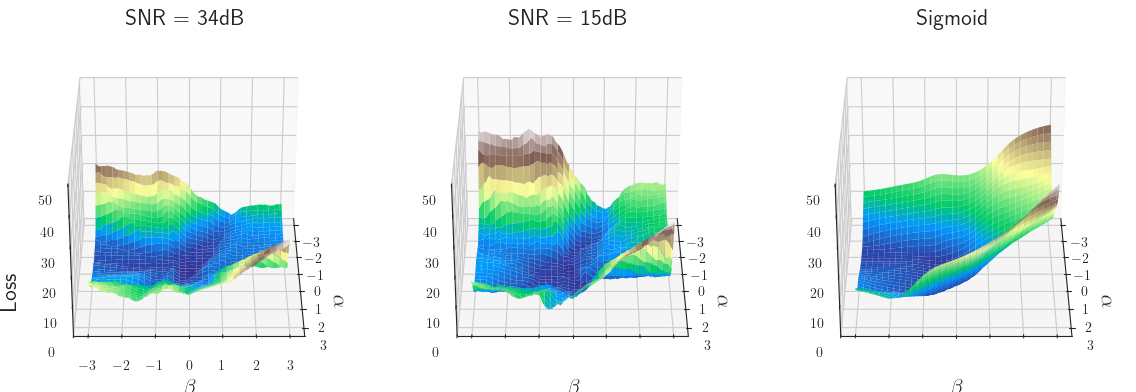

In [ ]:
def rotating_surfaces():

    with sns.axes_style("ticks"):
        fig, ax = plt.subplots(1, 3, figsize=(12, 5), subplot_kw={'projection': '3d'}, sharex=True, sharey=True)

        # plotting the 34dB SNR model
        ax[0].plot_surface(tri_34_grid[0], tri_34_grid[1], loss_surface_tr34, edgecolor="none", lw=0, cmap="terrain")
        ax[0].set_title("SNR = 34dB", fontsize=16)

        # plotting the 15dB SNR model
        ax[1].plot_surface(tri_15_grid[0], tri_15_grid[1], loss_surface_tr15, edgecolor="none", lw=0, cmap="terrain")
        ax[1].set_title("SNR = 15dB", fontsize=16)

        # plotting the sigmoid
        ax[2].plot_surface(grid_sig[0], grid_sig[1], loss_surface_sig, edgecolor="none", lw=0, cmap="terrain")
        ax[2].set_title("Sigmoid", fontsize=16)

        for i, axs in enumerate([ax[0], ax[1], ax[2]]):
            axs.set_zlim(0, 50)
            axs.set_xlabel(r"$\alpha$", fontsize=16)
            axs.set_ylabel(r"$\beta$", fontsize=16)
            if i == 0:
                axs.set_zlabel(r"Loss", rotation=90, fontsize=16, labelpad=10)

    # plt.tight_layout(rect=[0., 0., 0.9, 1.])
    plt.subplots_adjust(left=0.02, right=0.95, bottom=0.05, top=0.95, wspace=0.1)

    # animation: rotating the view
    def update_view(angle):
        for axs in ax:
            axs.view_init(elev=30, azim=angle)

        return fig
    
    # define angles to sweep over
    angles = jnp.arange(0, 360, 2)

    # create the animation
    anim = animation.FuncAnimation(
        fig,
        update_view,
        frames=angles,
        interval=50,
        blit=False
    )

    filename = os.path.join(FIGURES_PATH, "loss_landscape_rotating.gif")
    anim.save(filename, writer='pillow', fps=20)

    print(f"Animation saved to {filename}")


animate_flag_ = False
if animate_flag_:
    rotating_surfaces()